# Socioeconomic Bias in CLIP for Satellite Imagery
**Author:** Paula Font Solà  
**Course:** Deep Learning for Visual Signal Processing
**Date:** May 2026  

## Part 1: Ground Truth Dataset Generation
This notebook handles the creation of a custom dataset mapping high-resolution satellite imagery to real-world socioeconomic indicators. We focus on Madrid and Barcelona to capture distinct urban topologies. 

Our ground truth relies on the **INE (Instituto Nacional de Estadística)** Household Income Distribution Atlas at the census tract (*sección censal*) level. We will merge spatial data (shapefiles) with tabular income data, extract the geographic centroids, and fetch corresponding satellite tiles via API.

In [1]:
# Standard data manipulation
import pandas as pd
import numpy as np
import os

# Get and manage datasets
import urllib.request
import zipfile
import requests
import time
from tqdm import tqdm

# Spatial data manipulation
import geopandas as gpd
from shapely.geometry import Point

# Visualization
import matplotlib.pyplot as plt

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
KAGGLE_DIR = "/kaggle/working"
DATASET_DIR = "/kaggle/input/datasets/paulafontsola/individual-project-data"
def is_already_downloaded(path, debug=False):
    """
    Checks if a file exists in either of the two data folders.
    Returns True if it finds it, False if it doesn't.
    """
    kaggle_path = os.path.join(KAGGLE_DIR, path)
    dataset_path = os.path.join(DATASET_DIR, path)

    if debug:
        print("Searching in Kaggle Working Directory: ", kaggle_path)
        print("Searching in Dataset Directory: ", dataset_path)

    if os.path.exists(kaggle_path):
        return kaggle_path
    if os.path.exists(dataset_path):
        return dataset_path

    return os.path.exists(kaggle_path) or os.path.exists(dataset_path)

### 1.1 Loading Spatial and Tabular Data
We load the geographical boundaries of the census tracts (vector data) and the corresponding net income per household. 

*Note: The INE data requires merging based on the unique census tract identifier.*

In [3]:
os.makedirs("data", exist_ok=True)

# Direct URLs for download
shapefile_url = "https://www.ine.es/prodyser/cartografia/seccionado_2023.zip"
income_url_madrid = "https://www.ine.es/jaxiT3/files/t/es/csv_bdsc/31097.csv"
income_url_barcelona = "https://www.ine.es/jaxiT3/files/t/es/csv_bdsc/30896.csv"

# Define local save paths
shapefile_zip_path = "data/ine_cartography.zip"
income_csv_madrid_path = "data/ine_income_data_madrid.csv"
income_csv_barcelona_path = "data/ine_income_data_barcelona.csv"

# 1. Fully Automated Download
shapefile_file = is_already_downloaded(shapefile_zip_path)
if not shapefile_file:
    print("Downloading shapefiles...")
    urllib.request.urlretrieve(shapefile_url, shapefile_zip_path)
    print("Extracting shapefiles...")
    with zipfile.ZipFile(shapefile_zip_path, 'r') as zip_ref:
        zip_ref.extractall("data/shapefiles")
    shapefile_file = shapefile_zip_path
else:
    print("Shapefiles already downloaded.")

income_csv_madrid_file = is_already_downloaded(income_csv_madrid_path)
if not income_csv_madrid_file:
    print("Downloading Madrid income data...")
    urllib.request.urlretrieve(income_url_madrid, income_csv_madrid_path)
    income_csv_madrid_file = income_csv_madrid_path

income_csv_barcelona_file = is_already_downloaded(income_csv_barcelona_path)
if not is_already_downloaded(income_csv_barcelona_path):
    print("Downloading Barcelona income data...")
    urllib.request.urlretrieve(income_url_barcelona, income_csv_barcelona_path)
    income_csv_barcelona_file = income_csv_barcelona_path


print("Loading data into Pandas/Geopandas...")

# 2. Load the Spatial Data

shapefiles_path = os.path.join(
    os.path.dirname(shapefile_file), #Either points to the data folder in dataset or kaggle directory
    "shapefiles/España_Seccionado2023_ETRS89H30/SECC_CE_20230101.shp"
)
geo_df = gpd.read_file(shapefiles_path)

# 3. Load the Tabular Income Data
income_mad_df = pd.read_csv(income_csv_madrid_file, sep=';')
income_bcn_df = pd.read_csv(income_csv_barcelona_file, sep=';')

# Combine Madrid and Barcelona into one dataframe
income_df = pd.concat([income_mad_df, income_bcn_df], ignore_index=True)

# 4. Clean and Merge

# A. Filter out the noise
# Keep only the year 2023
income_df = income_df[income_df['Periodo'] == 2023]

# Keep only the "Net income per household" metric
income_df = income_df[income_df['Indicadores de renta media y mediana'] == 'Renta neta media por hogar']

# Drop the rows that are municipal averages (where 'Secciones' is blank/NaN)
income_df = income_df.dropna(subset=['Secciones'])

# B. Extract the clean codes
# The INE format is often "2807901001 Madrid centro". We just extract the first 10 characters.
income_df['CUSEC'] = income_df['Secciones'].astype(str).str[:10]

# C. Rename the value column
# The actual income value is stored in a column named 'Total'. Let's rename it to be descriptive.
income_df = income_df.rename(columns={'Total': 'net_income_per_household'})

# D. The Merge
# Ensure both columns are strings so we don't lose leading zeros
geo_df['CUSEC'] = geo_df['CUSEC'].astype(str)
income_df['CUSEC'] = income_df['CUSEC'].astype(str)

# Perform the inner merge
merged_df = geo_df.merge(income_df, on='CUSEC', how='inner')

print(f"Successfully merged {len(merged_df)} census tracts!")
merged_df[['CUSEC', 'net_income_per_household', 'geometry']].head()

Extracting shapefiles...
Loading data into Pandas/Geopandas...
Successfully merged 8121 census tracts!


,CUSEC,net_income_per_household,geometry
0,0800101001,42.674,"POLYGON ((909828.911 4606109.681, 909749.39 46..."
1,0800101002,39.672,"POLYGON ((909191.34 4608265.481, 909209.283 46..."
2,0800101003,60.829,"POLYGON ((911128.804 4605500.569, 911122.449 4..."
3,0800101004,48.145,"POLYGON ((908731.332 4608277.167, 908729.328 4..."
4,0800101005,40.695,"POLYGON ((909083.208 4607812.154, 909084.576 4..."


### 1.2 Geoprocessing: Centroid Extraction
To standardize our satellite image retrieval, we extract the exact center coordinate (centroid) of each census tract polygon. This coordinate will serve as the camera target for our satellite API request.

In [4]:
# Calculate the centroid of each polygon
# Note: We ensure the Coordinate Reference System (CRS) is WGS84 (Lat/Lon) which APIs use
merged_df = merged_df.to_crs(epsg=4326)
merged_df['centroid'] = merged_df.geometry.centroid

# Extract Latitude and Longitude into separate, clean columns for the API
merged_df['latitude'] = merged_df['centroid'].y
merged_df['longitude'] = merged_df['centroid'].x

print(f"Successfully calculated centroids for {len(merged_df)} census tracts.")

Successfully calculated centroids for 8121 census tracts.


### 1.3 Sanity Check: Visualizing the Ground Truth
Before querying the API, we map the income distribution to ensure our spatial merge was successful and to visualize the socioeconomic landscape we are testing CLIP against.

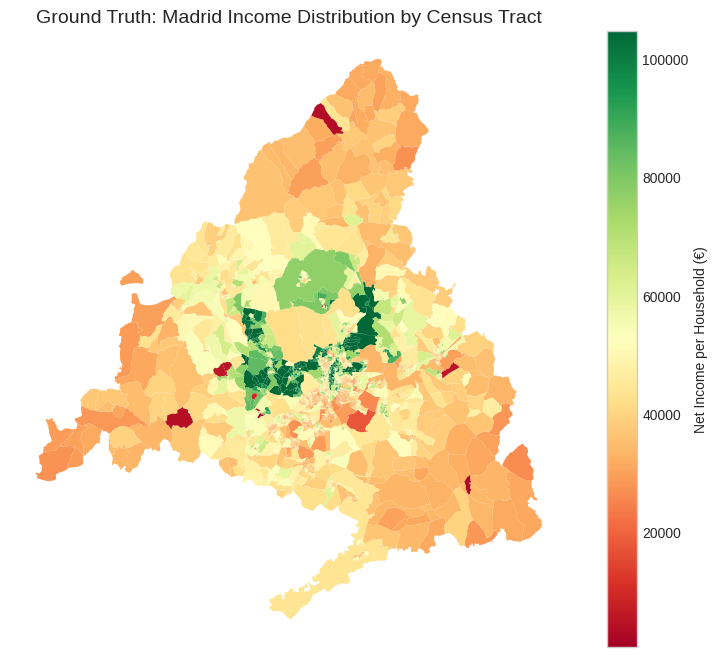

In [5]:
# The INE sometimes uses dots for thousands, so we clean the string first
merged_df['net_income_per_household'] = merged_df['net_income_per_household'].astype(str).str.replace('.', '', regex=False)
merged_df['net_income_per_household'] = pd.to_numeric(merged_df['net_income_per_household'], errors='coerce')

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# We filter for just Madrid (assuming province code '28') to make the plot readable
madrid_df = merged_df[merged_df['CUSEC'].str.startswith('28')]

# Plot the polygons using a color map (cmap) based on income
madrid_df.plot(column='net_income_per_household', 
               ax=ax, 
               legend=True,
               cmap='RdYlGn', # Red (Low Income) to Green (High Income)
               legend_kwds={'label': "Net Income per Household (€)"},
               missing_kwds={'color': 'lightgrey', 'label': 'No Data'}) # Added a safe fallback for missing data!

plt.title("Ground Truth: Madrid Income Distribution by Census Tract", fontsize=14)
plt.axis('off')
plt.show()

### 1.4 Combining Regional Income Data
Since we downloaded the income data for Madrid and Barcelona separately, we first concatenate them into a single dataframe before merging with our spatial geometries.

In [6]:
# 1. Load both CSVs
income_mad_df = pd.read_csv(income_csv_madrid_file, sep=';')
income_bcn_df = pd.read_csv(income_csv_barcelona_file, sep=';')

# 2. Combine them into one large dataframe
income_df = pd.concat([income_mad_df, income_bcn_df], ignore_index=True)

# 3. Clean the Combined Data (The Crucial Step!)
# Filter for the year 2023
income_df = income_df[income_df['Periodo'] == 2023]

# Filter for household income
income_df = income_df[income_df['Indicadores de renta media y mediana'] == 'Renta neta media por hogar']

# Drop rows that don't belong to a specific census tract
income_df = income_df.dropna(subset=['Secciones'])

# Rename 'Secciones' to 'CUSEC' so it matches our map data
income_df = income_df.rename(columns={'Secciones': 'CUSEC'})

# Extract just the 10-digit code (ignoring the text like "Madrid centro")
income_df['CUSEC'] = income_df['CUSEC'].astype(str).str[:10]

# Rename the final value column to be descriptive
income_df = income_df.rename(columns={'Total': 'net_income_per_household'})


# 4. Merge with the Shapefile (Assuming geo_df is already loaded in memory)
geo_df['CUSEC'] = geo_df['CUSEC'].astype(str)
merged_df = geo_df.merge(income_df, on='CUSEC', how='inner')


# 5. Calculate Centroids for the API
merged_df = merged_df.to_crs(epsg=4326) # Ensure standard Lat/Lon format
merged_df['centroid'] = merged_df.geometry.centroid
merged_df['latitude'] = merged_df['centroid'].y
merged_df['longitude'] = merged_df['centroid'].x

print(f"Data cleaned, merged, and centroids calculated for {len(merged_df)} tracts!")
merged_df[['CUSEC', 'net_income_per_household', 'latitude', 'longitude']].head()

Data cleaned, merged, and centroids calculated for 8121 tracts!


,CUSEC,net_income_per_household,latitude,longitude
0,0800101001,42.674,41.510509,1.905575
1,0800101002,39.672,41.520095,1.900875
2,0800101003,60.829,41.512993,1.912996
3,0800101004,48.145,41.514389,1.880540
4,0800101005,40.695,41.517519,1.899710


### 1.5 Fetching Satellite Imagery
Using the extracted centroids, we will now query the Google Maps Static API. For each census tract, we request a 512x512 high-resolution satellite tile at zoom level 17 (which clearly resolves buildings, streets, and vegetation).

*Note: We include a small delay in the loop to respect API rate limits.*

In [7]:
# Setup the directory
IMAGE_DIR = "/kaggle/working/data/satellite_images"
os.makedirs(IMAGE_DIR, exist_ok=True)

# Convert Degrees to Meters
# We convert our dataframe to EPSG:3857 (Web Mercator) so all coordinates are in METERS.
merged_df_meters = merged_df.to_crs(epsg=3857)

# Define how much ground the image should cover in meters (a 400x400m square)
TILE_SIZE_METERS = 400
half_size = TILE_SIZE_METERS / 2

print(f"Starting public WMS download for {len(merged_df_meters)} images...")
for index, row in tqdm(merged_df_meters.iterrows(), total=len(merged_df_meters)):
    cusec = row['CUSEC']
    centroid = row['geometry'].centroid # in meters
    cx, cy = centroid.x, centroid.y
    
    # Calculate the Bounding Box (minX, minY, maxX, maxY)
    minx = cx - half_size
    miny = cy - half_size
    maxx = cx + half_size
    maxy = cy + half_size
    
    # Format the BBOX
    bbox = f"{minx},{miny},{maxx},{maxy}"
    
    # Construct the IGN PNOA WMS URL
    # We request a 512x512 PNG image covering our exact bounding box
    wms_url = (
        "https://www.ign.es/wms-inspire/pnoa-ma?"
        "request=GetMap&"
        "service=WMS&"
        "version=1.3.0&"
        "layers=OI.OrthoimageCoverage&"
        "crs=EPSG:3857&"
        f"bbox={bbox}&"
        "width=512&"
        "height=512&"
        "format=image/png"
    )
    
    image_path = os.path.join("data/satellite_images", f"{cusec}.png")
    
    # Skip if already downloaded
    # print(image_path)
    if not is_already_downloaded(image_path, debug=False):
        #  print("Image not found")
        try:
            response = requests.get(wms_url, timeout=10)
            if response.status_code == 200:
                if 'image' in response.headers.get('Content-Type', ''):
                    with open(image_path, 'wb') as file:
                        file.write(response.content)
                else:
                    print(f"\nError fetching {cusec}: Server returned an error message instead of an image.")
                    pass # Silently skip WMS XML error messages
            else:
                print(f"\nError fetching {cusec}: HTTP {response.status_code}")
                pass    
        except requests.exceptions.RequestException as e:
            # If the connection resets, we just sleep for 2 seconds to let the server recover
            time.sleep(2)
        time.sleep(0.3)

print("Test download complete! Check your 'data/satellite_images' folder.")

Starting public WMS download for 8121 images...


 61%|██████    | 4925/8121 [05:35<17:50,  2.99it/s]


Error fetching 2807904029: HTTP 502


 61%|██████    | 4951/8121 [06:55<2:16:55,  2.59s/it]


Error fetching 2807904052: HTTP 502


...


Error fetching 2807908191: HTTP 502


100%|█████████▉| 8086/8121 [2:23:36<01:43,  2.97s/it]


Error fetching 0806901004: HTTP 502


100%|██████████| 8121/8121 [2:25:15<00:00,  1.07s/it]

Test download complete! Check your 'data/satellite_images' folder.


In [8]:
import shutil
shutil.make_archive('madrid_bcn_satellite_dataset', 'zip', 'data')
print("Dataset zipped successfully!")

Dataset zipped successfully!
